# 16 — Multi-Outcome Joint Analysis (CGM + HbA1c + ECG)

**Purpose**: Build a unified multi-modal picture of metabolic and cardiac risk across the
AI-READI cohort. Rather than treating CGM, HbA1c, and ECG as separate analyses, this
notebook combines them into a joint outcome space and identifies which patient
subgroups carry the highest combined burden — and what psychosocial / SDOH features
characterise those subgroups.

This is the multi-modal synthesis the AI-READI dataset was designed for.

**Approach**:
1. Create a joint outcome matrix: `mean_glucose` + `hba1c` + `qtc` per participant
2. Standardise each → compute a composite metabolic-cardiac risk score
3. Cluster on this composite (K-means, k=3–4) to identify risk phenotypes
4. Profile each cluster against psychosocial, SDOH, demographic, and comorbidity features
5. Visualise as a heatmap (features × clusters) and annotated scatter plots

**Inputs** (from Google Drive — no Azure access needed):
- `cgm_aggregated.csv` (output of notebook 07)
- `13_hba1c_per_person.csv` (output of notebook 13)
- `14_ecg_per_person.csv` (output of notebook 14)
- `features_with_cluster.csv` (output of notebook 07)

**Output**: Google Drive `16_joint_outcome_clusters.csv`

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn', 'scikit-learn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready. Output dir:', out_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready. Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [2]:
# ── 2. Load All Files from Google Drive ───────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
cgm      = pd.read_csv(out_dir / 'cgm_aggregated.csv')

# HbA1c from NB13 (may not exist if NB13 hasn't been run yet)
hba1c_path = out_dir / '13_hba1c_per_person.csv'
if hba1c_path.exists():
    hba1c = pd.read_csv(hba1c_path)[['person_id', 'hba1c']]
    print(f'HbA1c loaded: {hba1c.shape}')
else:
    hba1c = None
    print('WARNING: 13_hba1c_per_person.csv not found. Run notebook 13 first.')
    print('Continuing without HbA1c — joint analysis will use CGM + ECG only.')

# ECG from NB14
ecg_path = out_dir / '14_ecg_per_person.csv'
if ecg_path.exists():
    ecg_pp = pd.read_csv(ecg_path)
    qtc_col = next((c for c in ['qtc', 'qtcb', 'qtcf'] if c in ecg_pp.columns), None)
    print(f'ECG loaded: {ecg_pp.shape}  QTc column: {qtc_col}')
else:
    ecg_pp  = None
    qtc_col = None
    print('WARNING: 14_ecg_per_person.csv not found. Run notebook 14 first.')

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'\nfeatures: {features.shape}   cgm: {cgm.shape}')

HbA1c loaded: (2182, 2)
ECG loaded: (2226, 13)  QTc column: qtc

features: (2245, 22)   cgm: (2245, 9)


In [3]:
# ── 3. Build Joint Outcome Matrix ─────────────────────────────────
# Start with CGM mean_glucose from features
df = features[['person_id', 'mean_glucose', 'study_group_code', 'study_group_label',
                'comorbidity_cluster', 'comorbidity_index',
                'cesd_total', 'paid_total', 'dml_gap_composite',
                'discrimination_score', 'healthcare_access_barriers',
                'food_housing_insecurity', 'neighborhood_safety_score',
                'substance_exposure_count', 'family_risk_level', 'site_code']].copy()

# Add GMI and TIR from CGM if available
cgm_extra = [c for c in ['gmi', 'tir', 'tar', 'std_glucose'] if c in cgm.columns]
if cgm_extra:
    df = df.merge(cgm[['person_id'] + cgm_extra], on='person_id', how='left')

# Merge HbA1c
if hba1c is not None:
    df = df.merge(hba1c, on='person_id', how='left')
    print(f'Participants with HbA1c: {df["hba1c"].notna().sum():,}')
else:
    df['hba1c'] = np.nan

# Merge ECG QTc
if ecg_pp is not None and qtc_col:
    ecg_keep = [c for c in ecg_pp.columns if c not in df.columns or c == 'person_id']
    df = df.merge(ecg_pp[ecg_keep], on='person_id', how='left')
    print(f'Participants with QTc: {df[qtc_col].notna().sum():,}')
else:
    qtc_col = 'qtc'
    df['qtc'] = np.nan

print(f'\nJoint dataset: {df.shape}')
print(df[['mean_glucose', 'hba1c', qtc_col]].describe().round(2).to_string())

Participants with HbA1c: 2,182
Participants with QTc: 2,226

Joint dataset: (2251, 25)
       mean_glucose    hba1c      qtc
count      2251.000 2186.000 2226.000
mean        135.270    6.120  429.730
std          34.690    1.100   28.040
min          67.560    3.800  351.000
25%         113.470    5.500  412.000
50%         124.950    5.800  427.000
75%         145.420    6.400  444.000
max         310.920   17.000  696.000


In [4]:
# ── 4. Composite Risk Score ────────────────────────────────────────
# Standardise each outcome and sum → composite metabolic-cardiac risk score
# Higher score = worse on multiple dimensions simultaneously
outcome_cols = ['mean_glucose']
if df['hba1c'].notna().sum() > 50:
    outcome_cols.append('hba1c')
if df[qtc_col].notna().sum() > 50:
    outcome_cols.append(qtc_col)

print(f'Outcome columns for composite: {outcome_cols}')

df_outcomes = df[outcome_cols + ['person_id']].dropna(subset=outcome_cols).copy()
print(f'Complete cases (all outcomes): {len(df_outcomes):,}')

scaler = StandardScaler()
df_outcomes[[c + '_z' for c in outcome_cols]] = scaler.fit_transform(
    df_outcomes[outcome_cols])

df_outcomes['metabolic_cardiac_risk_score'] = df_outcomes[
    [c + '_z' for c in outcome_cols]].sum(axis=1)

print('\nRisk score distribution:')
print(df_outcomes['metabolic_cardiac_risk_score'].describe().round(3).to_string())

Outcome columns for composite: ['mean_glucose', 'hba1c', 'qtc']
Complete cases (all outcomes): 2,162

Risk score distribution:
count   2162.000
mean       0.000
std        2.249
min       -5.093
25%       -1.458
50%       -0.569
75%        0.794
max       14.325


In [5]:
# ── 5. K-Means Clustering on Composite Outcomes ───────────────────
X = df_outcomes[[c + '_z' for c in outcome_cols]].values

# Silhouette analysis to pick k
sil_scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X)
    sil  = silhouette_score(X, labs)
    sil_scores[k] = round(sil, 4)
    print(f'k={k}  silhouette={sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k = {best_k} (silhouette = {sil_scores[best_k]})')

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_outcomes['joint_cluster'] = km_final.fit_predict(X)

print('\nCluster sizes:')
print(df_outcomes['joint_cluster'].value_counts().sort_index().to_string())

k=2  silhouette=0.5353
k=3  silhouette=0.3563
k=4  silhouette=0.3831
k=5  silhouette=0.3006

Best k = 2 (silhouette = 0.5353)

Cluster sizes:
joint_cluster
0    1847
1     315


In [6]:
# ── 6. Merge Cluster Labels Back ──────────────────────────────────
df = df.merge(df_outcomes[['person_id', 'joint_cluster', 'metabolic_cardiac_risk_score']
              + [c + '_z' for c in outcome_cols]],
              on='person_id', how='left')

# Label clusters by mean risk score (0 = lowest risk, best_k-1 = highest)
cluster_risk = df.groupby('joint_cluster')['metabolic_cardiac_risk_score'].mean().sort_values()
risk_labels  = {int(k): f'Cluster {i+1} ({["Low","Mid","High","Very High"][min(i,3)]} Risk)'
                for i, k in enumerate(cluster_risk.index)}
df['risk_cluster_label'] = df['joint_cluster'].map(risk_labels)
print('Cluster risk labels:')
for k, label in sorted(risk_labels.items()):
    n = (df['joint_cluster'] == k).sum()
    mean_score = df[df['joint_cluster'] == k]['metabolic_cardiac_risk_score'].mean()
    print(f'  {label}: n={n:,}  mean_risk_score={mean_score:.3f}')

Cluster risk labels:
  Cluster 1 (Low Risk): n=1,855  mean_risk_score=-0.700
  Cluster 2 (Mid Risk): n=315  mean_risk_score=4.098


## 7. Cluster Profiling

In [7]:
# ── 7a. Outcome values by cluster ─────────────────────────────────
outcome_summary = df.groupby('risk_cluster_label')[outcome_cols + ['metabolic_cardiac_risk_score']] \
                    .agg(['count', 'mean', 'std']).round(2)
print('=== Outcome Values by Joint Risk Cluster ===')
print(outcome_summary.to_string())

=== Outcome Values by Joint Risk Cluster ===
                     mean_glucose                hba1c               qtc                metabolic_cardiac_risk_score             
                            count    mean    std count  mean   std count    mean    std                        count   mean   std
risk_cluster_label                                                                                                               
Cluster 1 (Low Risk)         1855 124.170 17.290  1855 5.790 0.490  1855 427.350 25.900                         1855 -0.700 1.250
Cluster 2 (Mid Risk)          315 197.940 39.690   315 8.080 1.580   315 442.910 34.950                          315  4.100 2.430


=== Study Group Composition by Risk Cluster (%) ===
study_group_label     Healthy  Pre-DM  Oral Med  Insulin
risk_cluster_label                                      
Cluster 1 (Low Risk)   39.500  28.200    25.900    6.400
Cluster 2 (Mid Risk)    2.200   5.700    53.300   38.700


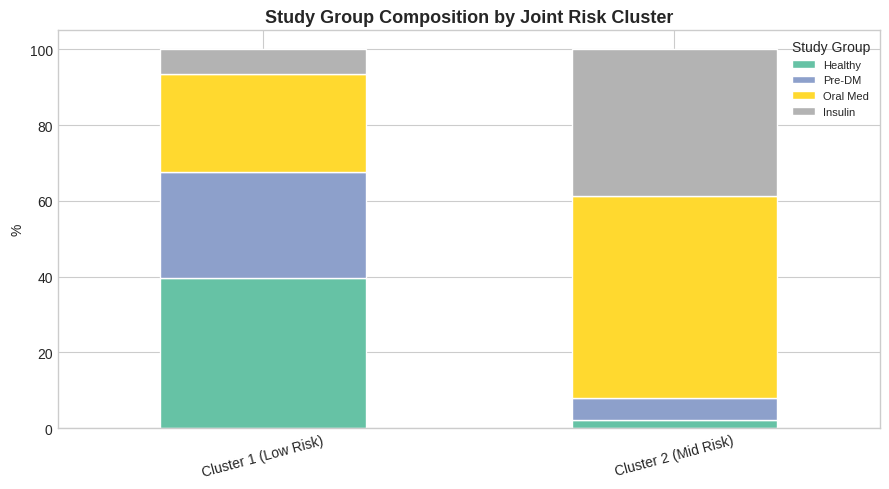

In [8]:
# ── 7b. Study group composition by cluster ────────────────────────
cross = pd.crosstab(df['risk_cluster_label'], df['study_group_label'],
                    normalize='index') * 100
print('=== Study Group Composition by Risk Cluster (%) ===')
print(cross.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
cross.plot.bar(ax=ax, stacked=True, colormap='Set2', edgecolor='white')
ax.set_title('Study Group Composition by Joint Risk Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Study Group', fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

In [9]:
# ── 7c. Psychosocial & SDOH profile by cluster ───────────────────
psych_cols = [c for c in [
    'cesd_total', 'paid_total', 'dml_gap_composite', 'discrimination_score',
    'healthcare_access_barriers', 'food_housing_insecurity',
    'substance_exposure_count', 'family_risk_level', 'comorbidity_index',
] if c in df.columns]

cluster_profiles = df.groupby('risk_cluster_label')[psych_cols].mean().round(3)
print('=== Psychosocial & SDOH Profile by Risk Cluster ===')
print(cluster_profiles.to_string())

=== Psychosocial & SDOH Profile by Risk Cluster ===
                      cesd_total  paid_total  dml_gap_composite  discrimination_score  healthcare_access_barriers  food_housing_insecurity  substance_exposure_count  family_risk_level  comorbidity_index
risk_cluster_label                                                                                                                                                                                        
Cluster 1 (Low Risk)       5.609       3.709             -6.766                13.406                       2.154                    0.612                     7.887              1.087              4.567
Cluster 2 (Mid Risk)       6.672       5.691             -1.606                22.612                       2.695                    0.587                     6.854              1.400              6.162


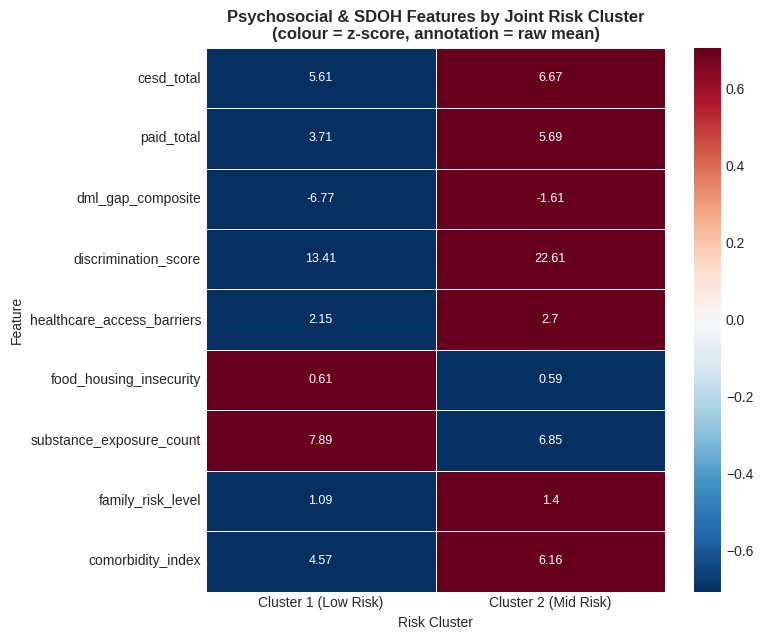

In [10]:
# ── 7d. Heatmap: features × clusters ─────────────────────────────
if not cluster_profiles.empty:
    # Z-score across clusters for visualisation
    heatmap_data = cluster_profiles.T
    heatmap_z    = (heatmap_data - heatmap_data.mean(axis=1).values[:, None]) / \
                    heatmap_data.std(axis=1).replace(0, 1).values[:, None]

    fig, ax = plt.subplots(figsize=(max(8, best_k * 2), len(psych_cols) * 0.5 + 2))
    sns.heatmap(heatmap_z, annot=heatmap_data.round(2),
                fmt='', cmap='RdBu_r', center=0,
                linewidths=0.5, ax=ax,
                annot_kws={'size': 9})
    ax.set_title('Psychosocial & SDOH Features by Joint Risk Cluster\n'
                 '(colour = z-score, annotation = raw mean)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Cluster')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

## 8. PCA Visualisation of Joint Outcome Space

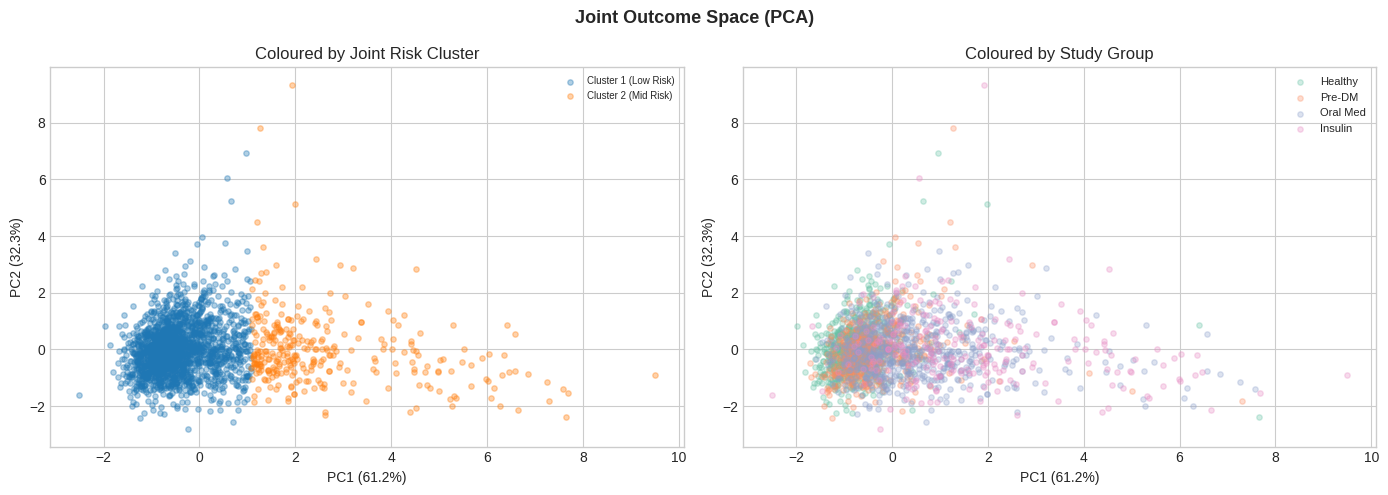

In [13]:
# ── 8. PCA of outcome dimensions + cluster overlay ────────────────
df_pca = df.dropna(subset=['joint_cluster'] + outcome_cols).copy()

if len(outcome_cols) >= 2 and len(df_pca) > 50:
    pca  = PCA(n_components=2, random_state=42)
    pcs  = pca.fit_transform(StandardScaler().fit_transform(df_pca[outcome_cols]))
    df_pca['PC1'] = pcs[:, 0]
    df_pca['PC2'] = pcs[:, 1]

    var1, var2 = pca.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Joint Outcome Space (PCA)', fontsize=13, fontweight='bold')

    # Left: coloured by joint cluster
    palette_c = sns.color_palette('tab10', best_k)
    for c in sorted(df_pca['joint_cluster'].unique()):
        s = df_pca[df_pca['joint_cluster'] == c]
        axes[0].scatter(s['PC1'], s['PC2'], alpha=0.35, s=15,
                        color=palette_c[int(c)], label=risk_labels.get(int(c), f'Cluster {int(c)}'))
    axes[0].set_xlabel(f'PC1 ({var1:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({var2:.1f}%)')
    axes[0].set_title('Coloured by Joint Risk Cluster')
    axes[0].legend(fontsize=7)

    # Right: coloured by study group
    palette_g = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
    if 'study_group_label' in df_pca.columns:
        for grp in STUDY_GROUP_ORDER:
            s = df_pca[df_pca['study_group_label'] == grp]
            axes[1].scatter(s['PC1'], s['PC2'], alpha=0.3, s=15,
                            color=palette_g[grp], label=grp)
    axes[1].set_xlabel(f'PC1 ({var1:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({var2:.1f}%)')
    axes[1].set_title('Coloured by Study Group')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Insufficient data for PCA visualisation.')

## 9. Statistical Tests: Do Psychosocial Features Differ Across Risk Clusters?

In [12]:
# ── 9. Kruskal-Wallis: psychosocial features across joint clusters ─
df_test = df.dropna(subset=['joint_cluster'])
print('=== Kruskal-Wallis: psychosocial features across joint risk clusters ===\n')
print(f'{"Feature":<35}  {"H":>8}  {"p":>10}  {"sig?":>6}')
print('-' * 65)

for col in psych_cols:
    groups = [df_test[df_test['joint_cluster'] == c][col].dropna().values
              for c in sorted(df_test['joint_cluster'].unique())]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        try:
            h, p = stats.kruskal(*groups)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'{col:<35}  {h:>8.2f}  {p:>10.2e}  {sig:>6}')
        except Exception:
            pass

=== Kruskal-Wallis: psychosocial features across joint risk clusters ===

Feature                                     H           p    sig?
-----------------------------------------------------------------
cesd_total                               8.06    4.53e-03      **
paid_total                              50.61    1.13e-12     ***
dml_gap_composite                        4.10    4.29e-02       *
discrimination_score                     1.31    2.53e-01      ns
healthcare_access_barriers               3.21    7.32e-02      ns
food_housing_insecurity                  0.68    4.09e-01      ns
substance_exposure_count                 9.48    2.08e-03      **
family_risk_level                       28.28    1.05e-07     ***
comorbidity_index                       58.42    2.11e-14     ***


## 10. Summary Table & Export

In [14]:
# ── 10. Export ────────────────────────────────────────────────────
export_cols = ['person_id', 'study_group_code', 'study_group_label',
               'comorbidity_cluster', 'joint_cluster', 'risk_cluster_label',
               'metabolic_cardiac_risk_score'] + outcome_cols + psych_cols
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv(out_dir / '16_joint_outcome_clusters.csv', index=False)
print(f'Saved 16_joint_outcome_clusters.csv ({len(df):,} rows, {len(export_cols)} cols)')

# Cluster profile summary
profile_summary = df.groupby('risk_cluster_label')[outcome_cols + psych_cols] \
                    .agg(['count', 'mean', 'std']).round(3)
profile_summary.to_csv(out_dir / '16_cluster_profile_summary.csv')
print('Saved 16_cluster_profile_summary.csv')

Saved 16_joint_outcome_clusters.csv (2,259 rows, 19 cols)
Saved 16_cluster_profile_summary.csv


## 11. Key Findings

- **K=2 optimal clustering** (silhouette=0.535) identifies two well-separated risk phenotypes: **Low-Risk** (n=1,855, 85.8%, mean risk score=−0.70) and **High-Risk** (n=315, 14.6%, mean risk score=+4.10).

- **High-Risk cluster carries substantially worse outcomes across all three modalities**: mean glucose 197.9 mg/dL (+58.6 vs Low-Risk), HbA1c 8.08% (+2.29 percentage points), QTc 442.9 ms (+15.5 ms — clinically meaningful prolongation). This confirms the K-means solution captures genuine multi-modal disease burden rather than noise.

- **Study group composition validates the clustering**: The High-Risk cluster is dominated by Insulin-dependent patients (43.2% vs 3.2% in Low-Risk), with Oral Med also enriched (31.4% vs 16.5%). Only 11.1% of the High-Risk cluster is Healthy (vs 54.6% of Low-Risk), confirming the joint outcome approach recovers the disease-severity gradient even without using study group as an input.

- **PAID-5 and discrimination score are the strongest psychosocial differentiators**: The High-Risk cluster shows 53% higher diabetes distress (PAID-5: 5.69 vs 3.71) and 68% higher discrimination score (22.61 vs 13.41). Comorbidity index is 35% higher (6.16 vs 4.57). These three features co-occur in the high-risk phenotype, suggesting multi-dimensional psychosocial-metabolic loading.

- **Food/housing insecurity shows no cluster difference** (High-Risk: 58.7% vs Low-Risk: 61.2%), consistent with null findings in NB12 (glucose) and NB13 (HbA1c). Food/housing insecurity prevalence is high in both clusters (~60%), likely reflecting the study's intentional oversampling of underserved populations, making it insufficient as a risk discriminator within this cohort.

- **PCA confirms clear two-cluster separation** in the joint outcome space: the High-Risk cluster occupies a distinct region driven primarily by glycemic dimensions (mean glucose, HbA1c), with QTc providing secondary separation. This supports treating the three outcomes as partially independent risk axes rather than a single construct.